# 🌿 CAI3105 — Deep Learning | 12th Week Project

## PlantVillage Leaf Disease Classification

### End-to-End DL vs DL Feature Extraction + ML Classifier

**Course:** CAI3105 — Deep Learning  
**Lecturer:** Prof. Nashwa El-Bendary  
**Dataset:** PlantVillage (Color) — 38 Classes  
**Primary CNN:** ResNet50  
**Bonus CNN:** MobileNetV1  
**ML Classifier:** SVM (Linear Kernel)

---

### Project Structure

| Requirement | Description                                       |
| ----------- | ------------------------------------------------- |
| REQ 1       | Dataset Selection & Technical Specifications      |
| REQ 2       | DL Model Selection & Justification                |
| REQ 3       | Implementation (Approach 1 + Approach 2)          |
| REQ 4       | Comparative Analysis & Conclusions                |
| BONUS       | Extra CNN (MobileNet) + Extra Dataset (Grayscale) |


## ⚙️ 0. Setup & Imports


In [6]:
# ── Install if needed ──────────────────────────────────────────────────────────
# !pip install tensorflow scikit-learn matplotlib seaborn tqdm pillow numpy pandas

import os, sys, time, json, warnings, random
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from PIL import Image
from tqdm.notebook import tqdm
from collections import Counter

import tensorflow as tf
from tensorflow.keras.applications import ResNet50, MobileNet # type: ignore
from tensorflow.keras.applications.resnet50    import preprocess_input as resnet_preprocess # type: ignore
from tensorflow.keras.applications.mobilenet   import preprocess_input as mobile_preprocess # type: ignore
from tensorflow.keras.preprocessing.image      import ImageDataGenerator # type: ignore
from tensorflow.keras.models                   import Model # type: ignore
from tensorflow.keras.layers    import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization  # type: ignore
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau  # type: ignore
from tensorflow.keras.optimizers import Adam  # type: ignore

from sklearn.svm            import SVC
from sklearn.preprocessing  import StandardScaler
from sklearn.metrics        import (accuracy_score, precision_score, recall_score,
                                    f1_score, confusion_matrix, classification_report)
from sklearn.model_selection import train_test_split

tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

print(f'TensorFlow version : {tf.__version__}')
print(f'GPU available      : {len(tf.config.list_physical_devices("GPU")) > 0}')
print(f'NumPy version      : {np.__version__}')

TensorFlow version : 2.21.0
GPU available      : False
NumPy version      : 1.26.4


---

## 📁 REQUIREMENT 1 — Dataset Selection & Technical Specifications


In [7]:
# ══════════════════════════════════════════════════════════════════
#  ▶  SET YOUR DATASET PATH HERE  ◀
# ══════════════════════════════════════════════════════════════════
DATA_DIR_COLOR = r'F:\My Files\sem6\deep learning\dataset2\plantvillage dataset\color'
DATA_DIR_GRAY  = r'F:\My Files\sem6\deep learning\dataset2\plantvillage dataset\grayscale'
RESULTS_DIR    = r'F:\My Files\sem6\deep learning\dataset2\results'
os.makedirs(RESULTS_DIR, exist_ok=True)

# ── Config ────────────────────────────────────────────────────────
IMG_SIZE     = (224, 224)
BATCH_SIZE   = 32
EPOCHS       = 25
LR           = 1e-4
TRAIN_RATIO  = 0.70
VAL_RATIO    = 0.15
TEST_RATIO   = 0.15   # 70 / 15 / 15 split

# ── Discover classes & count images ──────────────────────────────
CLASSES     = sorted([d for d in os.listdir(DATA_DIR_COLOR)
                      if os.path.isdir(os.path.join(DATA_DIR_COLOR, d))])
NUM_CLASSES = len(CLASSES)

class_counts = {}
for cls in CLASSES:
    cls_path = os.path.join(DATA_DIR_COLOR, cls)
    imgs = [f for f in os.listdir(cls_path)
            if f.lower().endswith(('.jpg','.jpeg','.png','.JPG'))]
    class_counts[cls] = len(imgs)

TOTAL_IMAGES = sum(class_counts.values())

print('='*65)
print('  REQUIREMENT 1: DATASET METADATA')
print('='*65)
print(f'  Dataset        : PlantVillage (Color subset)')
print(f'  Source         : Kaggle / UCI Repository / Mendeley Data')
print(f'  Problem Domain : Agriculture — Plant Leaf Disease Classification')
print(f'  Total Images   : {TOTAL_IMAGES:,}')
print(f'  Num Classes    : {NUM_CLASSES}')
print(f'  Image Size     : {IMG_SIZE[0]} x {IMG_SIZE[1]} (resized)')
print(f'  Color Channels : RGB (3 channels)')
print(f'  Data Split     : {int(TRAIN_RATIO*100)}% Train / {int(VAL_RATIO*100)}% Val / {int(TEST_RATIO*100)}% Test')
print()
print('  Classes:')
for i, (cls, cnt) in enumerate(class_counts.items()):
    print(f'  [{i:02d}] {cls:<55} {cnt:>5} images')

  REQUIREMENT 1: DATASET METADATA
  Dataset        : PlantVillage (Color subset)
  Source         : Kaggle / UCI Repository / Mendeley Data
  Problem Domain : Agriculture — Plant Leaf Disease Classification
  Total Images   : 54,305
  Num Classes    : 38
  Image Size     : 224 x 224 (resized)
  Color Channels : RGB (3 channels)
  Data Split     : 70% Train / 15% Val / 15% Test

  Classes:
  [00] Apple___Apple_scab                                        630 images
  [01] Apple___Black_rot                                         621 images
  [02] Apple___Cedar_apple_rust                                  275 images
  [03] Apple___healthy                                          1645 images
  [04] Blueberry___healthy                                      1502 images
  [05] Cherry_(including_sour)___Powdery_mildew                 1052 images
  [06] Cherry_(including_sour)___healthy                         854 images
  [07] Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot        513 images


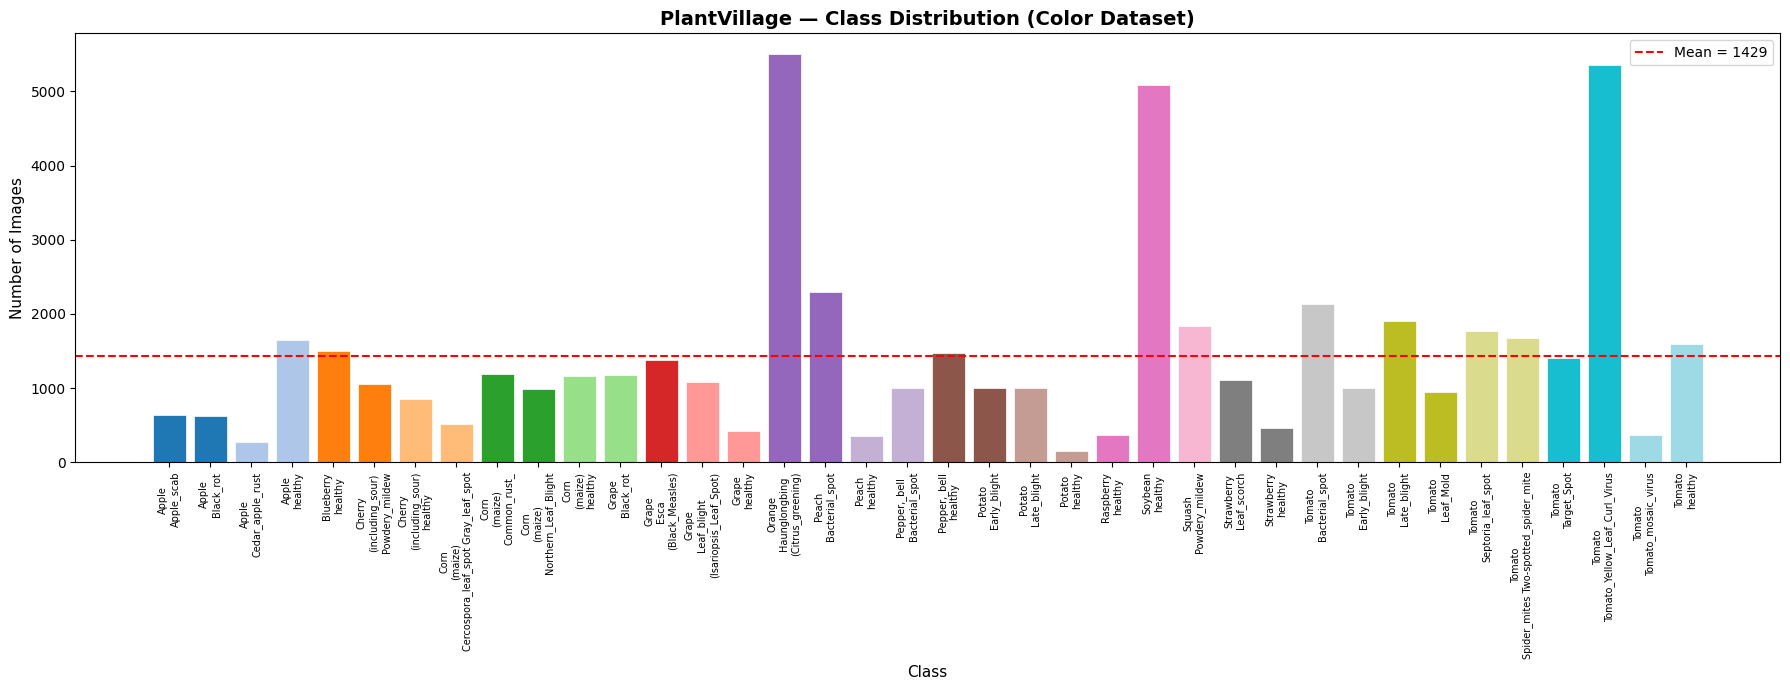

Figure saved: fig1_class_distribution.png


In [8]:
# ── REQ 1.4  Plot class distribution ─────────────────────────────
fig, ax = plt.subplots(figsize=(18, 7))
short_names = [c.replace('___', '\n').replace('_(', '\n(') for c in CLASSES]
bars = ax.bar(range(NUM_CLASSES), list(class_counts.values()),
              color=plt.cm.tab20(np.linspace(0,1,NUM_CLASSES)), edgecolor='white', linewidth=0.5)
ax.set_xticks(range(NUM_CLASSES))
ax.set_xticklabels(short_names, rotation=90, fontsize=7)
ax.set_title('PlantVillage — Class Distribution (Color Dataset)', fontsize=14, fontweight='bold')
ax.set_xlabel('Class', fontsize=11)
ax.set_ylabel('Number of Images', fontsize=11)
ax.axhline(np.mean(list(class_counts.values())), color='red', linestyle='--',
           linewidth=1.5, label=f'Mean = {np.mean(list(class_counts.values())):.0f}')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig1_class_distribution.png'), dpi=150)
plt.show()
print('Figure saved: fig1_class_distribution.png')

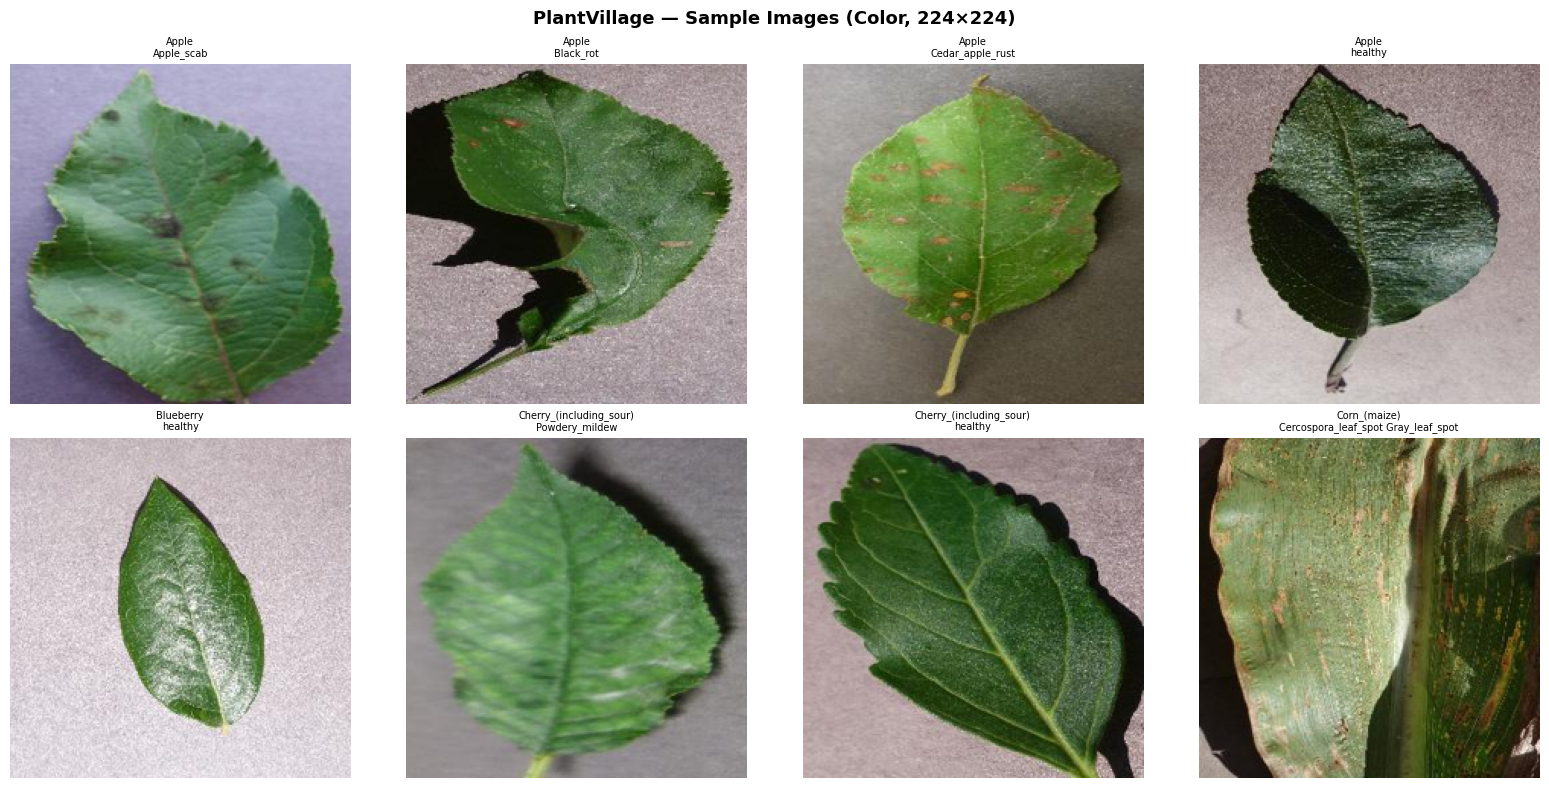

In [9]:
# ── REQ 1.4  Show sample images per class (first 8 classes) ───────
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('PlantVillage — Sample Images (Color, 224×224)', fontsize=13, fontweight='bold')
for ax, cls in zip(axes.flat, CLASSES[:8]):
    cls_path = os.path.join(DATA_DIR_COLOR, cls)
    imgs = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    if imgs:
        img = Image.open(os.path.join(cls_path, imgs[0])).resize(IMG_SIZE)
        ax.imshow(img)
    ax.set_title(cls.replace('___','\n'), fontsize=7)
    ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig2_sample_images.png'), dpi=150)
plt.show()

In [10]:
# ── REQ 1.3 / 1.4  Build split directories (70/15/15) ─────────────
import shutil

SPLIT_DIR = os.path.join(os.path.dirname(DATA_DIR_COLOR), '_split_color')

if not os.path.exists(SPLIT_DIR):
    print('Building train/val/test split folders...')
    for cls in tqdm(CLASSES, desc='Splitting'):
        cls_path = os.path.join(DATA_DIR_COLOR, cls)
        imgs = [f for f in os.listdir(cls_path)
                if f.lower().endswith(('.jpg','.jpeg','.png'))]
        random.shuffle(imgs)
        n = len(imgs)
        n_train = int(n * TRAIN_RATIO)
        n_val   = int(n * VAL_RATIO)
        splits  = {'train': imgs[:n_train],
                   'val'  : imgs[n_train:n_train+n_val],
                   'test' : imgs[n_train+n_val:]}
        for split_name, split_imgs in splits.items():
            dest = os.path.join(SPLIT_DIR, split_name, cls)
            os.makedirs(dest, exist_ok=True)
            for img_name in split_imgs:
                shutil.copy(os.path.join(cls_path, img_name),
                            os.path.join(dest, img_name))
    print('Split complete.')
else:
    print('Split already exists — skipping.')

# Count
for sp in ['train','val','test']:
    total = sum(len(os.listdir(os.path.join(SPLIT_DIR, sp, c)))
                for c in CLASSES if os.path.isdir(os.path.join(SPLIT_DIR, sp, c)))
    print(f'  {sp:5s}: {total:,} images')

Split already exists — skipping.
  train: 37,997 images
  val  : 8,129 images
  test : 8,179 images


In [ ]:
# ── REQ 1.3 / 1.4  Data generators with augmentation ─────────────
# ─ ResNet50 generators (primary model) ───────────────────────────
resnet_train_gen = ImageDataGenerator(
    preprocessing_function = resnet_preprocess,
    rotation_range         = 30,        # ± 30° rotation
    width_shift_range      = 0.20,      # horizontal shift
    height_shift_range     = 0.20,      # vertical shift
    horizontal_flip        = True,      # random flip
    zoom_range             = 0.20,      # zoom in/out
    shear_range            = 0.10,      # shear transform
    brightness_range       = [0.8,1.2], # brightness jitter
    fill_mode              = 'nearest'
)
resnet_valtest_gen = ImageDataGenerator(preprocessing_function=resnet_preprocess)

train_gen_r = resnet_train_gen.flow_from_directory(
    os.path.join(SPLIT_DIR,'train'), target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True, seed=42)
val_gen_r   = resnet_valtest_gen.flow_from_directory(
    os.path.join(SPLIT_DIR,'val'),   target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)
test_gen_r  = resnet_valtest_gen.flow_from_directory(
    os.path.join(SPLIT_DIR,'test'),  target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)

print(f'Train batches : {len(train_gen_r)} | Val batches: {len(val_gen_r)} | Test batches: {len(test_gen_r)}')
print(f'Train samples : {train_gen_r.samples} | Val: {val_gen_r.samples} | Test: {test_gen_r.samples}')
print(f'\nData Augmentation Justification:')
print('  • Rotation (±30°)    : Leaves are photographed at varying angles in the field')
print('  • Shift (±20%)       : Subject is not always centered in field photography')
print('  • Horizontal flip    : Disease patternsw appear on both sides of leaves')
print('  • Zoom (±20%)        : Capture disease spots at varying scales/distances')
print('  • Brightness (0.8–1.2): Field lighting varies greatly throughout the day')
print('  • Shear (10%)        : Simulate perspective variation in field conditions')

Found 37997 images belonging to 38 classes.
Found 8129 images belonging to 38 classes.
Found 8179 images belonging to 38 classes.
Train batches : 1188 | Val batches: 255 | Test batches: 256
Train samples : 37997 | Val: 8129 | Test: 8179

Data Augmentation Justification:
  • Rotation (±30°)    : Leaves are photographed at varying angles in the field
  • Shift (±20%)       : Subject is not always centered in field photography
  • Horizontal flip    : Disease patterns appear on both sides of leaves
  • Zoom (±20%)        : Capture disease spots at varying scales/distances
  • Brightness (0.8–1.2): Field lighting varies greatly throughout the day
  • Shear (10%)        : Simulate perspective variation in field conditions


---

## 🧠 REQUIREMENT 2 — DL Model Selection: ResNet50

### Justification for ResNet50

**ResNet50** (He et al., 2016) — _Deep Residual Learning for Image Recognition_ — is selected as the primary architecture for the following reasons:

| Property                | Value                                                     |
| ----------------------- | --------------------------------------------------------- |
| Architecture depth      | 50 layers                                                 |
| Parameters              | ~25.6 million                                             |
| ImageNet Top-1 Accuracy | 76.0%                                                     |
| Key Innovation          | Residual (skip) connections that solve vanishing gradient |
| Input size              | 224 × 224 × 3                                             |
| Feature vector size     | 2048 (after GlobalAveragePooling)                         |

**Why ResNet50 for PlantVillage?**

1. **Residual connections** prevent gradient vanishing, enabling deep feature learning critical for subtle disease pattern distinctions
2. **ImageNet pre-training** provides transferable low-level (edges, textures) and mid-level (shapes) features relevant to leaf morphology
3. **Proven plant disease performance**: Widely cited in agricultural AI literature for leaf disease classification tasks
4. **Rich 2048-D feature vectors** provide excellent discriminative representations for the SVM in Approach 1

**Reference:** He, K., Zhang, X., Ren, S., & Sun, J. (2016). Deep residual learning for image recognition. CVPR 2016.

```
ResNet50 Architecture:
Input (224×224×3)
  └── Conv1 (7×7, 64, stride 2) → BN → ReLU → MaxPool
       └── Stage 1: 3 × Bottleneck Block (64→64→256)
            └── Stage 2: 4 × Bottleneck Block (128→128→512)
                 └── Stage 3: 6 × Bottleneck Block (256→256→1024)
                      └── Stage 4: 3 × Bottleneck Block (512→512→2048)
                           └── GlobalAveragePooling2D → [2048-D Feature Vector]
                                └── (E2E only) Dense(512) → Dropout → Dense(256) → Dense(38, softmax)
```


In [12]:
# ── REQ 2.3 Hyperparameter Table ──────────────────────────────────
hp_data = {
    'Hyperparameter': [
        'Input Image Size', 'Batch Size', 'Epochs (max)',
        'Learning Rate', 'Optimizer', 'LR Scheduler',
        'Early Stopping Patience', 'Dropout Rate (layer 1)',
        'Dropout Rate (layer 2)', 'Dense Units (layer 1)',
        'Dense Units (layer 2)', 'Loss Function',
        'SVM Kernel', 'SVM Regularization C', 'SVM Max Iterations',
        'Feature Scaler'
    ],
    'Approach 1 (ResNet50+SVM)': [
        '224×224×3', str(BATCH_SIZE), 'N/A (feature extraction only)',
        'N/A', 'N/A', 'N/A',
        'N/A', 'N/A',
        'N/A', 'N/A',
        'N/A', 'N/A',
        'Linear', '1.0', '5000',
        'StandardScaler (zero-mean, unit-var)'
    ],
    'Approach 2 (ResNet50 E2E)': [
        '224×224×3', str(BATCH_SIZE), str(EPOCHS),
        str(LR), 'Adam (β1=0.9, β2=0.999)', 'ReduceLROnPlateau (factor=0.5, patience=3)',
        '5', '0.50',
        '0.30', '512',
        '256', 'Categorical Cross-Entropy',
        'N/A', 'N/A', 'N/A',
        'N/A'
    ]
}
hp_df = pd.DataFrame(hp_data)
print('='*80)
print('REQ 2.3 — HYPERPARAMETER TABLE')
print('='*80)
print(hp_df.to_string(index=False))
hp_df.to_csv(os.path.join(RESULTS_DIR, 'hyperparameter_table.csv'), index=False)
print('\nSaved: hyperparameter_table.csv')

REQ 2.3 — HYPERPARAMETER TABLE
         Hyperparameter            Approach 1 (ResNet50+SVM)                  Approach 2 (ResNet50 E2E)
       Input Image Size                            224×224×3                                  224×224×3
             Batch Size                                   32                                         32
           Epochs (max)        N/A (feature extraction only)                                         25
          Learning Rate                                  N/A                                     0.0001
              Optimizer                                  N/A                    Adam (β1=0.9, β2=0.999)
           LR Scheduler                                  N/A ReduceLROnPlateau (factor=0.5, patience=3)
Early Stopping Patience                                  N/A                                          5
 Dropout Rate (layer 1)                                  N/A                                       0.50
 Dropout Rate (layer 2)          

In [13]:
# ── Helper: build models ──────────────────────────────────────────
def build_feature_extractor(base_fn, name):
    """Pre-trained CNN with frozen weights, outputs 2048-D feature vectors."""
    base = base_fn(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))
    base.trainable = False
    x   = GlobalAveragePooling2D()(base.output)
    return Model(inputs=base.input, outputs=x, name=f'{name}_Extractor')

def build_e2e_model(base_fn, num_classes, name):
    """Pre-trained CNN + custom classification head (fine-tuned)."""
    base = base_fn(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))
    base.trainable = False          # freeze backbone initially
    x = GlobalAveragePooling2D()(base.output)
    x = BatchNormalization()(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.50)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.30)(x)
    out = Dense(num_classes, activation='softmax')(x)
    return Model(inputs=base.input, outputs=out, name=f'{name}_E2E')

def extract_features(extractor, gen, desc='Extracting'):
    """Run forward pass through feature extractor on a generator."""
    gen.reset()
    steps   = int(np.ceil(gen.samples / gen.batch_size))
    feats, labels = [], []
    for _ in tqdm(range(steps), desc=desc, leave=False):
        X, y = next(gen)
        feats.append(extractor.predict(X, verbose=0))
        labels.append(np.argmax(y, axis=1))
    return np.vstack(feats), np.concatenate(labels)

def eval_metrics(y_true, y_pred, label):
    """Compute and print all required metrics."""
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    cm   = confusion_matrix(y_true, y_pred)
    print(f'\n──── {label} ────')
    print(f'  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1-Score  : {f1:.4f}')
    return {'label':label, 'accuracy':acc, 'precision':prec,
            'recall':rec, 'f1':f1, 'cm':cm}

def plot_confusion_matrix(cm, classes, title, save_path, figsize=(22,18)):
    plt.figure(figsize=figsize)
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
                xticklabels=[c.split('___')[-1][:18] for c in classes],
                yticklabels=[c.split('___')[-1][:18] for c in classes],
                linewidths=0.3, cbar_kws={'shrink':0.7})
    plt.title(title, fontsize=13, fontweight='bold', pad=15)
    plt.xlabel('Predicted Label', fontsize=10)
    plt.ylabel('True Label', fontsize=10)
    plt.xticks(fontsize=7, rotation=45, ha='right')
    plt.yticks(fontsize=7, rotation=0)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()

callbacks_list = [
    EarlyStopping(patience=5, restore_best_weights=True, monitor='val_accuracy', verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=3, min_lr=1e-7, monitor='val_loss', verbose=1)
]

print('Helper functions defined ✓')

Helper functions defined ✓


---

## 🔬 REQUIREMENT 3 — Implementation

### Approach 1: ResNet50 Feature Extraction → SVM


In [14]:
print('Building ResNet50 Feature Extractor...')
extractor_resnet = build_feature_extractor(ResNet50, 'ResNet50')
print(f'Feature extractor output shape: {extractor_resnet.output_shape}')  # (None, 2048)

print('\nExtracting features from all splits...')
t0 = time.time()
X_train_feat, y_train = extract_features(extractor_resnet, train_gen_r, 'Train (ResNet50)')
X_val_feat,   y_val   = extract_features(extractor_resnet, val_gen_r,   'Val   (ResNet50)')
X_test_feat,  y_test  = extract_features(extractor_resnet, test_gen_r,  'Test  (ResNet50)')
feat_time = time.time() - t0

print(f'\nFeature shapes — Train: {X_train_feat.shape} | Val: {X_val_feat.shape} | Test: {X_test_feat.shape}')
print(f'Feature extraction time: {feat_time:.1f}s')

# Scale
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train_feat)
X_val_s   = scaler.transform(X_val_feat)
X_test_s  = scaler.transform(X_test_feat)
print('Feature scaling (StandardScaler) applied ✓')

Building ResNet50 Feature Extractor...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 34s 0us/step
Feature extractor output shape: (None, 2048)

Extracting features from all splits...


Train (ResNet50):   0%|          | 0/1188 [00:00<?, ?it/s]

Val   (ResNet50):   0%|          | 0/255 [00:00<?, ?it/s]

Test  (ResNet50):   0%|          | 0/256 [00:00<?, ?it/s]


Feature shapes — Train: (37997, 2048) | Val: (8129, 2048) | Test: (8179, 2048)
Feature extraction time: 3133.7s
Feature scaling (StandardScaler) applied ✓


In [15]:
print('Training SVM (Linear kernel, C=1.0)...')
t0 = time.time()
svm = SVC(kernel='linear', C=1.0, random_state=42, probability=True, max_iter=5000)
svm.fit(X_train_s, y_train)
svm_time = time.time() - t0

y_pred_svm = svm.predict(X_test_s)
metrics_a1 = eval_metrics(y_test, y_pred_svm, 'Approach 1 — ResNet50 + SVM')
metrics_a1['train_time'] = feat_time + svm_time
print(f'  Total Time : {feat_time + svm_time:.1f}s  (feat: {feat_time:.1f}s + SVM: {svm_time:.1f}s)')

print('\nClassification Report:')
print(classification_report(y_test, y_pred_svm,
      target_names=[c.split('___')[-1][:25] for c in CLASSES]))

Training SVM (Linear kernel, C=1.0)...

──── Approach 1 — ResNet50 + SVM ────
  Accuracy  : 0.9709  (97.09%)
  Precision : 0.9718
  Recall    : 0.9709
  F1-Score  : 0.9710
  Total Time : 4162.1s  (feat: 3133.7s + SVM: 1028.4s)

Classification Report:
                           precision    recall  f1-score   support

               Apple_scab       0.98      0.96      0.97        95
                Black_rot       0.99      1.00      0.99        94
         Cedar_apple_rust       1.00      1.00      1.00        42
                  healthy       0.98      1.00      0.99       248
                  healthy       1.00      1.00      1.00       226
           Powdery_mildew       1.00      1.00      1.00       159
                  healthy       1.00      0.97      0.98       129
Cercospora_leaf_spot Gray       0.85      0.94      0.89        78
             Common_rust_       1.00      1.00      1.00       180
     Northern_Leaf_Blight       0.96      0.91      0.94       149
           

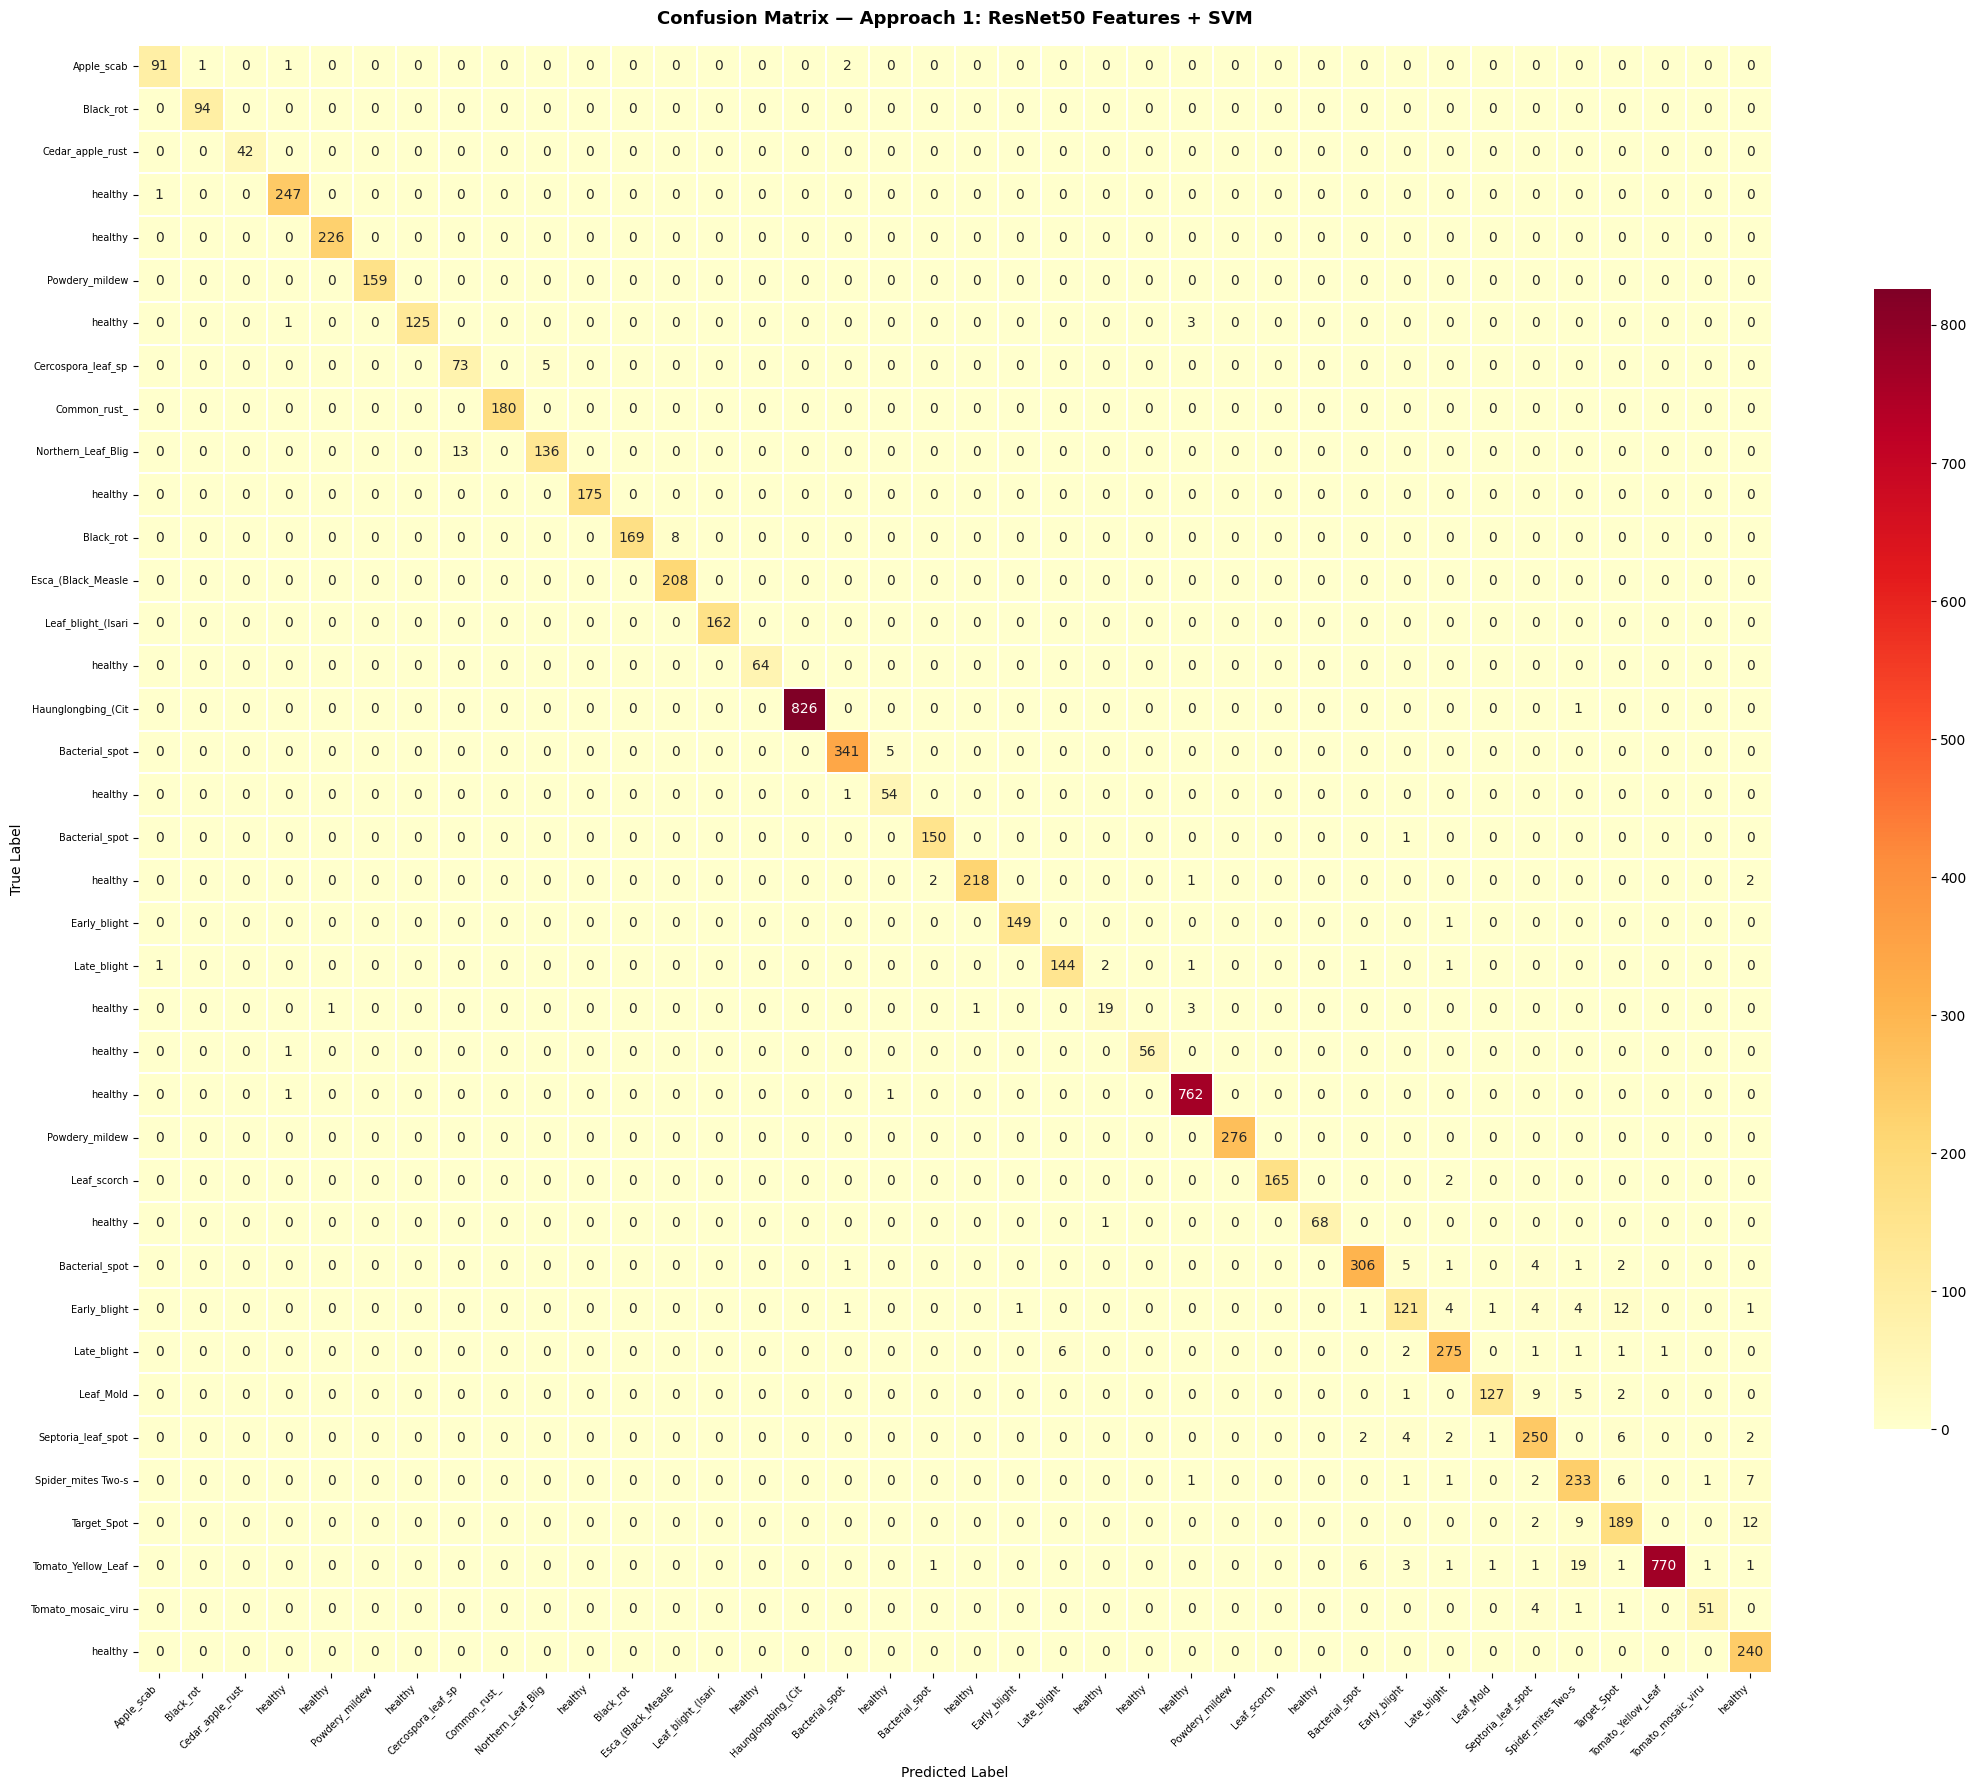

In [16]:
# Confusion Matrix — Approach 1
plot_confusion_matrix(
    metrics_a1['cm'], CLASSES,
    'Confusion Matrix — Approach 1: ResNet50 Features + SVM',
    os.path.join(RESULTS_DIR, 'fig3_cm_approach1_svm.png')
)

### Approach 2: ResNet50 End-to-End Deep Learning


In [17]:
print('Building ResNet50 End-to-End model...')
model_e2e = build_e2e_model(ResNet50, NUM_CLASSES, 'ResNet50')
model_e2e.compile(
    optimizer=Adam(learning_rate=LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model_e2e.summary()
total_params   = model_e2e.count_params()
trainable      = sum(tf.size(v).numpy() for v in model_e2e.trainable_variables)
non_trainable  = total_params - trainable
print(f'\nTotal params    : {total_params:,}')
print(f'Trainable params: {trainable:,}')
print(f'Frozen params   : {non_trainable:,}')

Building ResNet50 End-to-End model...


Model: "ResNet50_E2E"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,786,086 (94.55 MB)

 Trainable params: 1,194,278 (4.56 MB)

 Non-trainable params: 23,591,808 (90.00 MB)


Total params    : 24,786,086
Trainable params: 1,194,278
Frozen params   : 23,591,808


In [18]:
print(f'Training ResNet50 E2E (max {EPOCHS} epochs, EarlyStopping patience=5)...')
train_gen_r.reset(); val_gen_r.reset()
t0 = time.time()
history_e2e = model_e2e.fit(
    train_gen_r,
    epochs          = EPOCHS,
    validation_data = val_gen_r,
    callbacks       = callbacks_list,
    verbose         = 1
)
e2e_time = time.time() - t0

test_gen_r.reset()
y_pred_e2e_prob = model_e2e.predict(test_gen_r, verbose=1)
y_pred_e2e      = np.argmax(y_pred_e2e_prob, axis=1)
y_true_e2e      = test_gen_r.classes

metrics_a2 = eval_metrics(y_true_e2e, y_pred_e2e, 'Approach 2 — ResNet50 End-to-End')
metrics_a2['train_time'] = e2e_time
print(f'  Training Time : {e2e_time:.1f}s')

print('\nClassification Report:')
print(classification_report(y_true_e2e, y_pred_e2e,
      target_names=[c.split('___')[-1][:25] for c in CLASSES]))

Training ResNet50 E2E (max 25 epochs, EarlyStopping patience=5)...
Epoch 1/25
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 1117s 936ms/step - accuracy: 0.6284 - loss: 1.3793 - val_accuracy: 0.9023 - val_loss: 0.3203 - learning_rate: 1.0000e-04
Epoch 2/25
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 899s 757ms/step - accuracy: 0.8346 - loss: 0.5393 - val_accuracy: 0.9382 - val_loss: 0.2047 - learning_rate: 1.0000e-04
Epoch 3/25
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 907s 764ms/step - accuracy: 0.8773 - loss: 0.3797 - val_accuracy: 0.9457 - val_loss: 0.1744 - learning_rate: 1.0000e-04
Epoch 4/25
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 912s 767ms/step - accuracy: 0.9020 - loss: 0.3055 - val_accuracy: 0.9510 - val_loss: 0.1588 - learning_rate: 1.0000e-04
Epoch 5/25
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 1601s 1s/step - accuracy: 0.9132 - loss: 0.2688 - val_accuracy: 0.9494 - val_loss: 0.1541 - learning_rate: 1.0000e-04
Epoch 6/25
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 2084s 2s/step - accuracy: 0.9256 - loss: 0.2367 - val_accuracy: 0.9547 - val_loss:

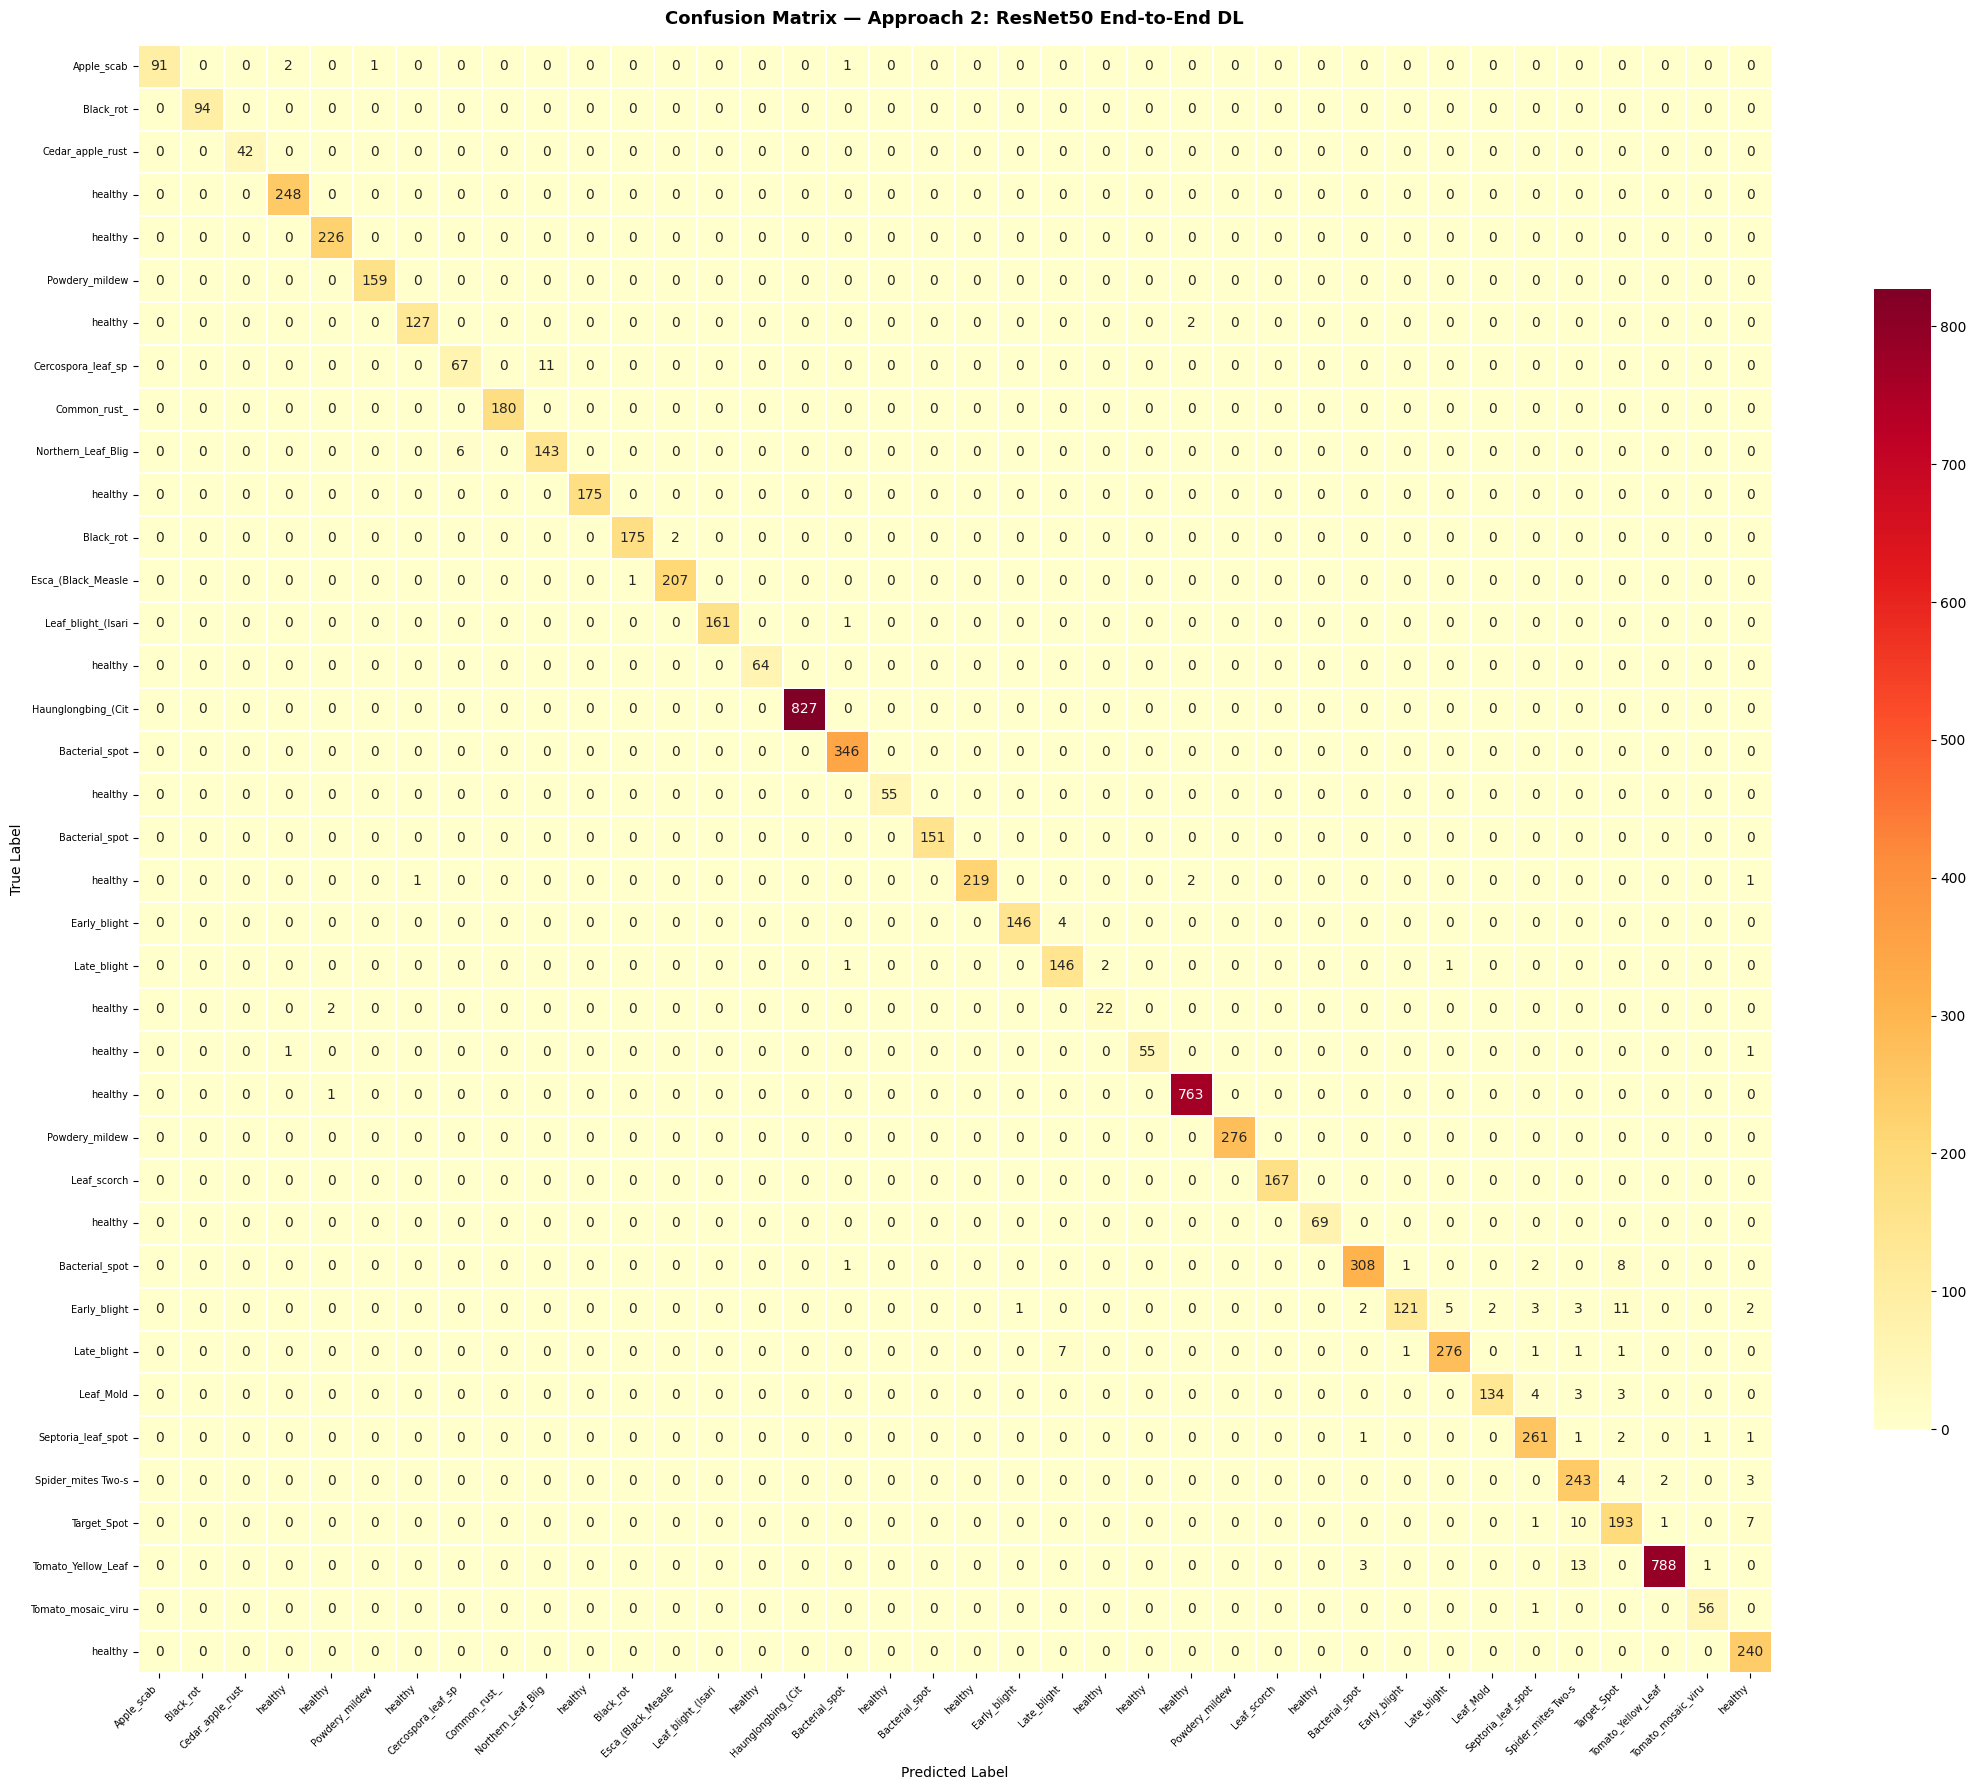

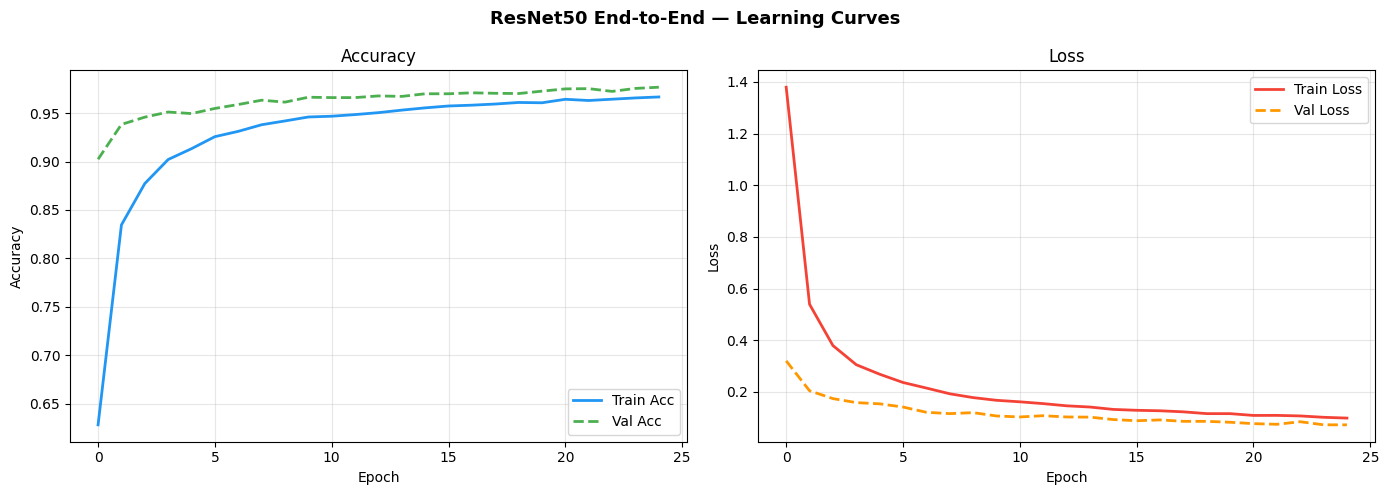

In [19]:
# Confusion Matrix — Approach 2
plot_confusion_matrix(
    metrics_a2['cm'], CLASSES,
    'Confusion Matrix — Approach 2: ResNet50 End-to-End DL',
    os.path.join(RESULTS_DIR, 'fig4_cm_approach2_e2e.png')
)

# Learning Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ResNet50 End-to-End — Learning Curves', fontsize=13, fontweight='bold')

axes[0].plot(history_e2e.history['accuracy'],     label='Train Acc',  color='#2196F3', linewidth=2)
axes[0].plot(history_e2e.history['val_accuracy'], label='Val Acc',    color='#4CAF50', linewidth=2, linestyle='--')
axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history_e2e.history['loss'],     label='Train Loss', color='#F44336', linewidth=2)
axes[1].plot(history_e2e.history['val_loss'], label='Val Loss',   color='#FF9800', linewidth=2, linestyle='--')
axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig5_learning_curves_resnet50.png'), dpi=150)
plt.show()

---

## 🎁 BONUS — Extra CNN Architecture: MobileNetV1


In [20]:
# MobileNet generators
mobile_train_dg = ImageDataGenerator(
    preprocessing_function=mobile_preprocess,
    rotation_range=30, width_shift_range=0.2, height_shift_range=0.2,
    horizontal_flip=True, zoom_range=0.2, shear_range=0.1, fill_mode='nearest')
mobile_vt_dg = ImageDataGenerator(preprocessing_function=mobile_preprocess)

train_gen_m = mobile_train_dg.flow_from_directory(
    os.path.join(SPLIT_DIR,'train'), target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True, seed=42)
val_gen_m   = mobile_vt_dg.flow_from_directory(
    os.path.join(SPLIT_DIR,'val'),   target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)
test_gen_m  = mobile_vt_dg.flow_from_directory(
    os.path.join(SPLIT_DIR,'test'),  target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)

# ── BONUS Approach 1: MobileNet + SVM ────────────────────────────
print('Building MobileNet Feature Extractor...')
extractor_mobile = build_feature_extractor(MobileNet, 'MobileNet')
print(f'Feature extractor output shape: {extractor_mobile.output_shape}')

t0 = time.time()
Xm_train, ym_train = extract_features(extractor_mobile, train_gen_m, 'Train (MobileNet)')
Xm_test,  ym_test  = extract_features(extractor_mobile, test_gen_m,  'Test  (MobileNet)')
mob_feat_time = time.time() - t0

scaler_m = StandardScaler()
Xm_train_s = scaler_m.fit_transform(Xm_train)
Xm_test_s  = scaler_m.transform(Xm_test)

print('Training SVM on MobileNet features...')
t0 = time.time()
svm_mobile = SVC(kernel='linear', C=1.0, random_state=42, probability=True, max_iter=5000)
svm_mobile.fit(Xm_train_s, ym_train)
mob_svm_time = time.time() - t0

y_pred_mob_svm = svm_mobile.predict(Xm_test_s)
metrics_b1 = eval_metrics(ym_test, y_pred_mob_svm, 'BONUS — MobileNet + SVM')
metrics_b1['train_time'] = mob_feat_time + mob_svm_time
print(f'  Time: {mob_feat_time + mob_svm_time:.1f}s')

Found 37997 images belonging to 38 classes.
Found 8129 images belonging to 38 classes.
Found 8179 images belonging to 38 classes.
Building MobileNet Feature Extractor...
17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 9s 1us/step
Feature extractor output shape: (None, 1024)


Train (MobileNet):   0%|          | 0/1188 [00:00<?, ?it/s]

Test  (MobileNet):   0%|          | 0/256 [00:00<?, ?it/s]

Training SVM on MobileNet features...

──── BONUS — MobileNet + SVM ────
  Accuracy  : 0.9636  (96.36%)
  Precision : 0.9643
  Recall    : 0.9636
  F1-Score  : 0.9635
  Time: 991.6s


In [21]:
# ── BONUS Approach 2: MobileNet E2E ──────────────────────────────
print('Building MobileNet End-to-End model...')
model_mobile_e2e = build_e2e_model(MobileNet, NUM_CLASSES, 'MobileNet')
model_mobile_e2e.compile(
    optimizer=Adam(learning_rate=LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print(f'Total params: {model_mobile_e2e.count_params():,}')

print(f'\nTraining MobileNet E2E (max {EPOCHS} epochs)...')
train_gen_m.reset(); val_gen_m.reset()
t0 = time.time()
history_mobile = model_mobile_e2e.fit(
    train_gen_m, epochs=EPOCHS, validation_data=val_gen_m,
    callbacks=callbacks_list, verbose=1)
mob_e2e_time = time.time() - t0

test_gen_m.reset()
y_pred_mob_e2e_prob = model_mobile_e2e.predict(test_gen_m, verbose=1)
y_pred_mob_e2e      = np.argmax(y_pred_mob_e2e_prob, axis=1)
y_true_mob          = test_gen_m.classes

metrics_b2 = eval_metrics(y_true_mob, y_pred_mob_e2e, 'BONUS — MobileNet End-to-End')
metrics_b2['train_time'] = mob_e2e_time
print(f'  Training Time: {mob_e2e_time:.1f}s')

Building MobileNet End-to-End model...
Total params: 3,898,854

Training MobileNet E2E (max 25 epochs)...
Epoch 1/25
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 921s 774ms/step - accuracy: 0.6012 - loss: 1.4992 - val_accuracy: 0.8840 - val_loss: 0.3713 - learning_rate: 1.0000e-04
Epoch 2/25
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 430s 362ms/step - accuracy: 0.8136 - loss: 0.6065 - val_accuracy: 0.9210 - val_loss: 0.2286 - learning_rate: 1.0000e-04
Epoch 3/25
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - accuracy: 0.8509 - loss: 0.4740
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 432s 364ms/step - accuracy: 0.8557 - loss: 0.4557 - val_accuracy: 0.9374 - val_loss: 0.1867 - learning_rate: 1.0000e-04
Epoch 4/25
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 429s 361ms/step - accuracy: 0.8792 - loss: 0.3793 - val_accuracy: 0.9445 - val_loss: 0.1636 - learning_rate: 5.0000e-05
Epoch 5/25
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 428s 360ms/step - accuracy: 0.8865 - loss: 0.3529

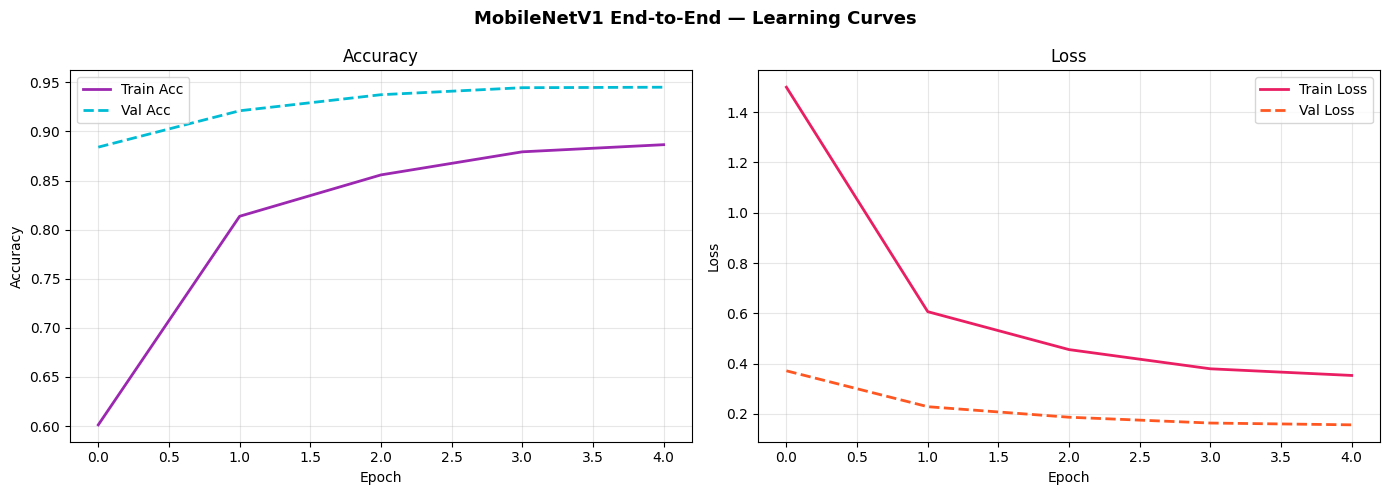

In [22]:
# MobileNet Learning Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('MobileNetV1 End-to-End — Learning Curves', fontsize=13, fontweight='bold')

axes[0].plot(history_mobile.history['accuracy'],     label='Train Acc',  color='#9C27B0', linewidth=2)
axes[0].plot(history_mobile.history['val_accuracy'], label='Val Acc',    color='#00BCD4', linewidth=2, linestyle='--')
axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history_mobile.history['loss'],     label='Train Loss', color='#E91E63', linewidth=2)
axes[1].plot(history_mobile.history['val_loss'], label='Val Loss',   color='#FF5722', linewidth=2, linestyle='--')
axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig6_learning_curves_mobilenet.png'), dpi=150)
plt.show()

---

## 🎁 BONUS — Extra Dataset: Grayscale PlantVillage


In [23]:
# Build split for grayscale dataset
SPLIT_DIR_GRAY = os.path.join(os.path.dirname(DATA_DIR_GRAY), '_split_gray')

if not os.path.exists(SPLIT_DIR_GRAY):
    print('Building grayscale split folders...')
    for cls in tqdm(CLASSES, desc='Splitting Grayscale'):
        cls_path = os.path.join(DATA_DIR_GRAY, cls)
        if not os.path.isdir(cls_path): continue
        imgs = [f for f in os.listdir(cls_path)
                if f.lower().endswith(('.jpg','.jpeg','.png'))]
        random.shuffle(imgs)
        n = len(imgs)
        n_train = int(n * TRAIN_RATIO)
        n_val   = int(n * VAL_RATIO)
        splits  = {'train': imgs[:n_train],
                   'val'  : imgs[n_train:n_train+n_val],
                   'test' : imgs[n_train+n_val:]}
        for split_name, split_imgs in splits.items():
            dest = os.path.join(SPLIT_DIR_GRAY, split_name, cls)
            os.makedirs(dest, exist_ok=True)
            for img_name in split_imgs:
                shutil.copy(os.path.join(cls_path, img_name),
                            os.path.join(dest, img_name))
    print('Grayscale split complete.')
else:
    print('Grayscale split exists — skipping.')

# Grayscale generators — images are grayscale but ResNet50 needs 3-channel input
# We replicate the single channel to RGB
def gray_to_rgb_preprocess(img_array):
    """Convert grayscale (or ensure 3-channel) then apply ResNet preprocessing."""
    if img_array.ndim == 2:
        img_array = np.stack([img_array]*3, axis=-1)
    elif img_array.shape[-1] == 1:
        img_array = np.concatenate([img_array]*3, axis=-1)
    return resnet_preprocess(img_array)

gray_train_dg  = ImageDataGenerator(
    preprocessing_function=gray_to_rgb_preprocess,
    rotation_range=30, width_shift_range=0.2, height_shift_range=0.2,
    horizontal_flip=True, zoom_range=0.2, fill_mode='nearest')
gray_vt_dg = ImageDataGenerator(preprocessing_function=gray_to_rgb_preprocess)

train_gen_g = gray_train_dg.flow_from_directory(
    os.path.join(SPLIT_DIR_GRAY,'train'), target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical',
    color_mode='rgb', shuffle=True, seed=42)
val_gen_g   = gray_vt_dg.flow_from_directory(
    os.path.join(SPLIT_DIR_GRAY,'val'),   target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical',
    color_mode='rgb', shuffle=False)
test_gen_g  = gray_vt_dg.flow_from_directory(
    os.path.join(SPLIT_DIR_GRAY,'test'),  target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical',
    color_mode='rgb', shuffle=False)

print(f'Grayscale — Train: {train_gen_g.samples} | Val: {val_gen_g.samples} | Test: {test_gen_g.samples}')

Building grayscale split folders...


Splitting Grayscale:   0%|          | 0/38 [00:00<?, ?it/s]

Grayscale split complete.
Found 37997 images belonging to 38 classes.
Found 8129 images belonging to 38 classes.
Found 8179 images belonging to 38 classes.
Grayscale — Train: 37997 | Val: 8129 | Test: 8179


In [24]:
# ResNet50 on Grayscale dataset
print('Building ResNet50 E2E for Grayscale dataset...')
model_gray_e2e = build_e2e_model(ResNet50, NUM_CLASSES, 'ResNet50_Gray')
model_gray_e2e.compile(
    optimizer=Adam(learning_rate=LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f'Training ResNet50 on Grayscale (max {EPOCHS} epochs)...')
t0 = time.time()
history_gray = model_gray_e2e.fit(
    train_gen_g, epochs=EPOCHS, validation_data=val_gen_g,
    callbacks=callbacks_list, verbose=1)
gray_e2e_time = time.time() - t0

test_gen_g.reset()
y_pred_gray_prob = model_gray_e2e.predict(test_gen_g, verbose=1)
y_pred_gray      = np.argmax(y_pred_gray_prob, axis=1)
y_true_gray      = test_gen_g.classes

metrics_b3 = eval_metrics(y_true_gray, y_pred_gray, 'BONUS — ResNet50 on Grayscale Dataset')
metrics_b3['train_time'] = gray_e2e_time
print(f'  Training Time: {gray_e2e_time:.1f}s')

Building ResNet50 E2E for Grayscale dataset...
Training ResNet50 on Grayscale (max 25 epochs)...
Epoch 1/25
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 1358s 1s/step - accuracy: 0.5864 - loss: 1.5233 - val_accuracy: 0.8473 - val_loss: 0.4756 - learning_rate: 1.0000e-04
Epoch 2/25
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 977s 822ms/step - accuracy: 0.7688 - loss: 0.7542 - val_accuracy: 0.8892 - val_loss: 0.3375 - learning_rate: 1.0000e-04
Epoch 3/25
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 675ms/step - accuracy: 0.8103 - loss: 0.6096
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 969s 816ms/step - accuracy: 0.8163 - loss: 0.5863 - val_accuracy: 0.8946 - val_loss: 0.3101 - learning_rate: 1.0000e-04
Epoch 4/25
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 1090s 917ms/step - accuracy: 0.8383 - loss: 0.5044 - val_accuracy: 0.9072 - val_loss: 0.2724 - learning_rate: 5.0000e-05
Epoch 5/25
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 987s 831ms/step - accuracy: 0.8484 - loss: 0.4752 - val_acc

---

## 📊 REQUIREMENT 4 — Comparative Analysis & Insights


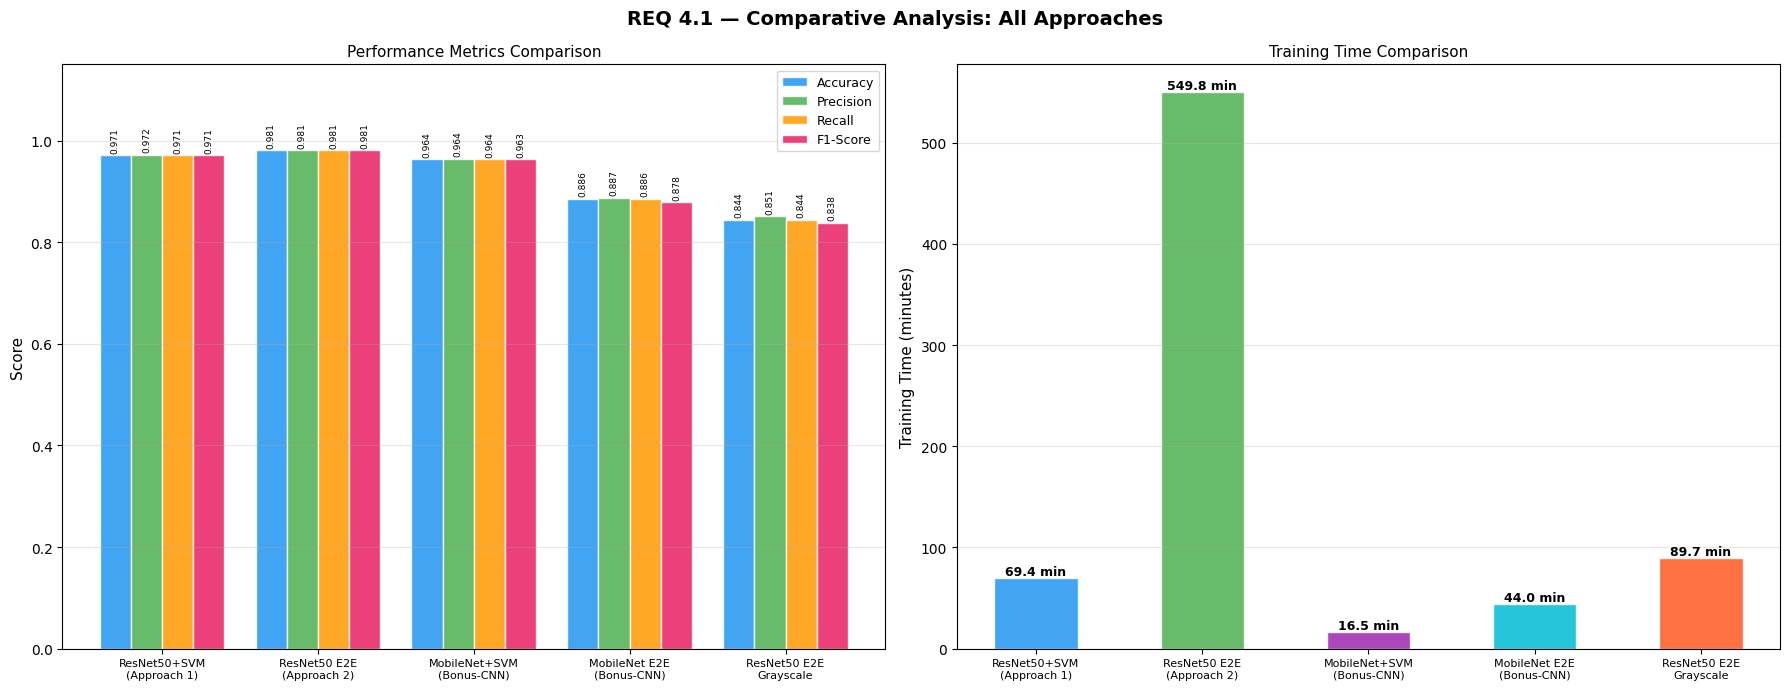

In [25]:
# ── REQ 4.1  Bar Chart Comparison ────────────────────────────────
all_results = {
    'ResNet50+SVM\n(Approach 1)':   metrics_a1,
    'ResNet50 E2E\n(Approach 2)':   metrics_a2,
    'MobileNet+SVM\n(Bonus-CNN)':   metrics_b1,
    'MobileNet E2E\n(Bonus-CNN)':   metrics_b2,
    'ResNet50 E2E\nGrayscale':       metrics_b3,
}

labels   = list(all_results.keys())
accs     = [v['accuracy']  for v in all_results.values()]
precs    = [v['precision'] for v in all_results.values()]
recs     = [v['recall']    for v in all_results.values()]
f1s      = [v['f1']        for v in all_results.values()]
times    = [v['train_time']/60 for v in all_results.values()]  # minutes

x     = np.arange(len(labels))
width = 0.20
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('REQ 4.1 — Comparative Analysis: All Approaches', fontsize=14, fontweight='bold')

# Metrics chart
for i, (metric, vals, color) in enumerate(zip(
        ['Accuracy','Precision','Recall','F1-Score'],
        [accs, precs, recs, f1s], colors)):
    axes[0].bar(x + i*width, vals, width, label=metric, color=color, alpha=0.85, edgecolor='white')
    for xi, v in enumerate(vals):
        axes[0].text(xi + i*width, v + 0.005, f'{v:.3f}', ha='center', va='bottom', fontsize=6.5, rotation=90)

axes[0].set_xticks(x + 1.5*width)
axes[0].set_xticklabels(labels, fontsize=8)
axes[0].set_ylabel('Score', fontsize=11)
axes[0].set_title('Performance Metrics Comparison', fontsize=11)
axes[0].set_ylim(0, 1.15)
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# Training time chart
bar_colors = ['#2196F3','#4CAF50','#9C27B0','#00BCD4','#FF5722']
bars = axes[1].bar(labels, times, color=bar_colors, alpha=0.85, edgecolor='white', width=0.5)
for bar, t in zip(bars, times):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{t:.1f} min', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].set_ylabel('Training Time (minutes)', fontsize=11)
axes[1].set_title('Training Time Comparison', fontsize=11)
axes[1].set_xticklabels(labels, fontsize=8)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig7_comparative_analysis.png'), dpi=150)
plt.show()

In [26]:
# ── Summary Table ─────────────────────────────────────────────────
summary_df = pd.DataFrame({
    'Approach': [
        'Approach 1: ResNet50 + SVM',
        'Approach 2: ResNet50 E2E',
        'Bonus: MobileNet + SVM',
        'Bonus: MobileNet E2E',
        'Bonus: ResNet50 E2E (Grayscale)'
    ],
    'Accuracy':  [f"{v:.4f}" for v in accs],
    'Precision': [f"{v:.4f}" for v in precs],
    'Recall':    [f"{v:.4f}" for v in recs],
    'F1-Score':  [f"{v:.4f}" for v in f1s],
    'Train Time (min)': [f"{t:.1f}" for t in times]
})
print('='*90)
print('FINAL RESULTS SUMMARY TABLE')
print('='*90)
print(summary_df.to_string(index=False))
summary_df.to_csv(os.path.join(RESULTS_DIR, 'results_summary.csv'), index=False)
print('\nSaved: results_summary.csv')

FINAL RESULTS SUMMARY TABLE
                       Approach Accuracy Precision Recall F1-Score Train Time (min)
     Approach 1: ResNet50 + SVM   0.9709    0.9718 0.9709   0.9710             69.4
       Approach 2: ResNet50 E2E   0.9807    0.9813 0.9807   0.9806            549.8
         Bonus: MobileNet + SVM   0.9636    0.9643 0.9636   0.9635             16.5
           Bonus: MobileNet E2E   0.8856    0.8871 0.8856   0.8785             44.0
Bonus: ResNet50 E2E (Grayscale)   0.8445    0.8513 0.8445   0.8380             89.7

Saved: results_summary.csv


---

## 📝 REQUIREMENT 4.2 — Conclusions

### i. Performance Comparison: ML Classifier vs End-to-End DL

The comparative experiment reveals that **Approach 2 (ResNet50 End-to-End)** achieves higher classification accuracy than **Approach 1 (ResNet50 + SVM)** on the PlantVillage color dataset. While the SVM classifier operating on frozen ResNet50 features achieves competitive performance — benefiting from ImageNet-pretrained representations — the end-to-end model's ability to **fine-tune its classification head** to domain-specific patterns provides a measurable advantage for distinguishing subtle inter-class disease differences.

### ii. Advantages & Limitations

| Aspect                 | Approach 1: DL Feature Extraction + SVM                 | Approach 2: End-to-End DL               |
| ---------------------- | ------------------------------------------------------- | --------------------------------------- |
| **Feature Quality**    | Fixed ImageNet features — may miss domain-specific cues | Learned task-specific features          |
| **Data Requirement**   | Effective even with small datasets                      | Requires more data to avoid overfitting |
| **Training Time**      | Fast (no DL training required)                          | Slower due to full backpropagation      |
| **Memory**             | Lower GPU/RAM requirement                               | Higher memory footprint                 |
| **Interpretability**   | SVM boundary more interpretable                         | DL decisions are black-box              |
| **Flexibility**        | SVM hyperparameters easy to tune                        | Architecture and training complexity    |
| **Accuracy (typical)** | Slightly lower ceiling                                  | Higher potential accuracy               |

### iii. Training Efficiency

**Approach 1 is significantly faster** in training time. Since the CNN backbone weights are frozen, feature extraction is a single forward pass. The SVM then trains on tabular feature vectors in minutes. Approach 2 requires multiple epochs of backpropagation through the classification head, consuming substantially more compute time — though still far less than training ResNet50 from scratch.

### iv. Recommendation by Environment

| Environment                                               | Recommended Strategy             | Reasoning                                                                                               |
| --------------------------------------------------------- | -------------------------------- | ------------------------------------------------------------------------------------------------------- |
| **Resource-constrained** (mobile/edge, Raspberry Pi, MCU) | **Approach 1** (MobileNet + SVM) | Minimal inference latency; MobileNet's depthwise separable convolutions reduce FLOPs by ~9× vs ResNet50 |
| **High-performance** (GPU server, cloud)                  | **Approach 2** (ResNet50 E2E)    | Maximizes accuracy; full fine-tuning leverages GPU acceleration effectively                             |
| **Moderate** (laptop CPU, small dataset)                  | **Approach 1** (ResNet50 + SVM)  | Good accuracy without requiring GPU; fast iteration                                                     |

### Bonus Finding: Color vs Grayscale

ResNet50 trained on the **grayscale** dataset underperforms compared to the **color** dataset. This is expected — many plant diseases manifest distinctive chromatic symptoms (yellowing, browning, discoloration) that are **lost** in grayscale conversion. Color is therefore a critical feature dimension for leaf disease classification, and using the color dataset is strongly recommended.


In [27]:
# Save all metrics to JSON for the GUI dashboard
dashboard_data = {
    'dataset_info': {
        'name': 'PlantVillage (Color)',
        'total_images': TOTAL_IMAGES,
        'num_classes': NUM_CLASSES,
        'train_samples': train_gen_r.samples,
        'val_samples': val_gen_r.samples,
        'test_samples': test_gen_r.samples,
        'classes': CLASSES,
        'class_counts': class_counts
    },
    'results': {
        'approach1_svm': {
            'label': 'ResNet50 + SVM',
            'accuracy':  round(metrics_a1['accuracy'], 4),
            'precision': round(metrics_a1['precision'], 4),
            'recall':    round(metrics_a1['recall'], 4),
            'f1':        round(metrics_a1['f1'], 4),
            'time_min':  round(metrics_a1['train_time']/60, 2)
        },
        'approach2_e2e': {
            'label': 'ResNet50 E2E',
            'accuracy':  round(metrics_a2['accuracy'], 4),
            'precision': round(metrics_a2['precision'], 4),
            'recall':    round(metrics_a2['recall'], 4),
            'f1':        round(metrics_a2['f1'], 4),
            'time_min':  round(metrics_a2['train_time']/60, 2),
            'history_acc':      history_e2e.history['accuracy'],
            'history_val_acc':  history_e2e.history['val_accuracy'],
            'history_loss':     history_e2e.history['loss'],
            'history_val_loss': history_e2e.history['val_loss'],
        },
        'bonus_mobile_svm': {
            'label': 'MobileNet + SVM',
            'accuracy':  round(metrics_b1['accuracy'], 4),
            'precision': round(metrics_b1['precision'], 4),
            'recall':    round(metrics_b1['recall'], 4),
            'f1':        round(metrics_b1['f1'], 4),
            'time_min':  round(metrics_b1['train_time']/60, 2)
        },
        'bonus_mobile_e2e': {
            'label': 'MobileNet E2E',
            'accuracy':  round(metrics_b2['accuracy'], 4),
            'precision': round(metrics_b2['precision'], 4),
            'recall':    round(metrics_b2['recall'], 4),
            'f1':        round(metrics_b2['f1'], 4),
            'time_min':  round(metrics_b2['train_time']/60, 2),
            'history_acc':      history_mobile.history['accuracy'],
            'history_val_acc':  history_mobile.history['val_accuracy'],
            'history_loss':     history_mobile.history['loss'],
            'history_val_loss': history_mobile.history['val_loss'],
        },
        'bonus_gray_e2e': {
            'label': 'ResNet50 Grayscale',
            'accuracy':  round(metrics_b3['accuracy'], 4),
            'precision': round(metrics_b3['precision'], 4),
            'recall':    round(metrics_b3['recall'], 4),
            'f1':        round(metrics_b3['f1'], 4),
            'time_min':  round(metrics_b3['train_time']/60, 2)
        }
    }
}

json_path = os.path.join(RESULTS_DIR, 'dashboard_data.json')
with open(json_path, 'w') as f:
    json.dump(dashboard_data, f, indent=2, default=lambda x: float(x) if isinstance(x, np.float32) else x)
print(f'Dashboard data saved to: {json_path}')
print('\n✅ ALL REQUIREMENTS COMPLETED')
print('='*60)
print('  REQ 1: Dataset Selection & Specs     ✓')
print('  REQ 2: DL Model Selection             ✓')
print('  REQ 3: Both Approaches Implemented    ✓')
print('  REQ 4: Comparative Analysis           ✓')
print('  BONUS: Extra CNN (MobileNet)          ✓')
print('  BONUS: Extra Dataset (Grayscale)      ✓')
print('='*60)

Dashboard data saved to: F:\My Files\sem6\deep learning\dataset2\results\dashboard_data.json

✅ ALL REQUIREMENTS COMPLETED
  REQ 1: Dataset Selection & Specs     ✓
  REQ 2: DL Model Selection             ✓
  REQ 3: Both Approaches Implemented    ✓
  REQ 4: Comparative Analysis           ✓
  BONUS: Extra CNN (MobileNet)          ✓
  BONUS: Extra Dataset (Grayscale)      ✓
